# Insights Generation

In this notebook, we will generate business insights from the clustered customer data. We will profile each cluster, visualize the segments, and provide recommendations for marketing actions.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the clustered customer data from the modeling notebook
data = pd.read_csv('../data/processed/rfm_scaled.csv')

# Load cluster assignments (we'll recreate them)
from sklearn.cluster import KMeans

numeric_data = data[['Recency', 'Frequency', 'Monetary']]
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(numeric_data)
data['Cluster'] = clusters

# Display the first few rows of the data
print(f"Data shape: {data.shape}")
print(f"Cluster distribution: \n{data['Cluster'].value_counts().sort_index()}")
data.head()

Data shape: (3949, 5)
Cluster distribution: 
Cluster
0    1002
1     778
2    2046
3     123
Name: count, dtype: int64


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,2.210736,-0.777296,-1.050747,0
1,12348.0,-0.238759,-0.401135,1.157604,1
2,12349.0,-0.785260,0.143651,1.108835,1
3,12350.0,2.054593,-0.582730,-0.639855,0
4,12352.0,-0.619358,0.429015,0.848168,1


## Cluster Profiling

We will analyze the characteristics of each cluster to understand the different customer segments.

In [2]:
# Profile the clusters - analyze characteristics of each segment
cluster_profiles = data.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].agg(['mean', 'median', 'std'])
print("Cluster Profiles (Scaled Values):")
print(cluster_profiles.round(4))
print("\n")

# Get cluster sizes
cluster_sizes = data['Cluster'].value_counts().sort_index()
print("Cluster Sizes:")
print(cluster_sizes)

Cluster Profiles (Scaled Values):
        Recency                 Frequency                 Monetary          \
           mean  median     std      mean  median     std     mean  median   
Cluster                                                                      
0        1.5119  1.4691  0.6402   -0.5015 -0.5827  0.3069  -0.6280 -0.7176   
1       -0.5775 -0.7267  0.4413    0.7698  0.6949  0.6875   1.4784  1.3261   
2       -0.4773 -0.5706  0.3804   -0.2858 -0.3882  0.4158  -0.3620 -0.4418   
3       -0.7246 -0.8145  0.3025    3.9699  3.4642  1.6077   1.7868  1.8798   

                 
            std  
Cluster          
0        0.4117  
1        0.8233  
2        0.4413  
3        0.8970  


Cluster Sizes:
Cluster
0    1002
1     778
2    2046
3     123
Name: count, dtype: int64


## Visualizing Cluster Profiles

Let's visualize the cluster profiles to better understand the differences between segments.

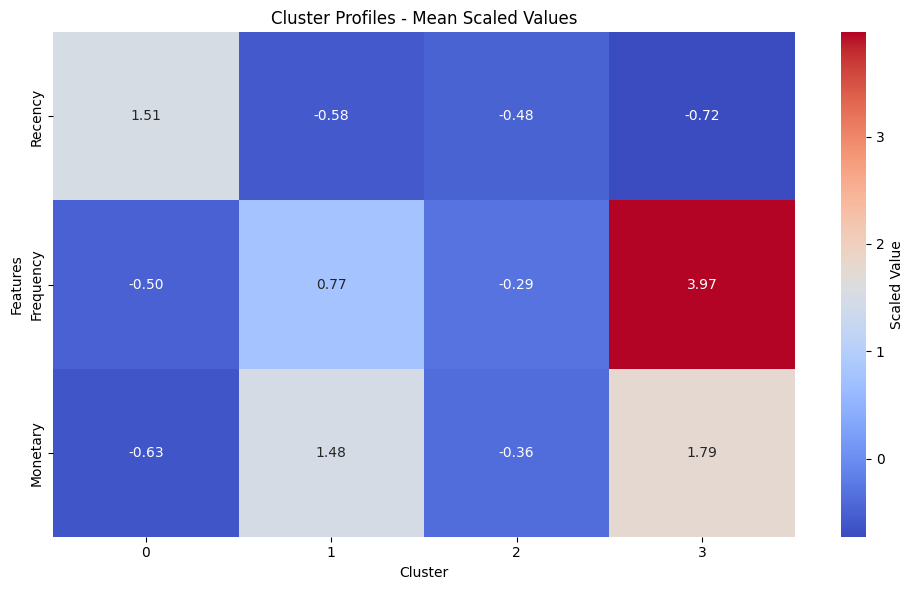

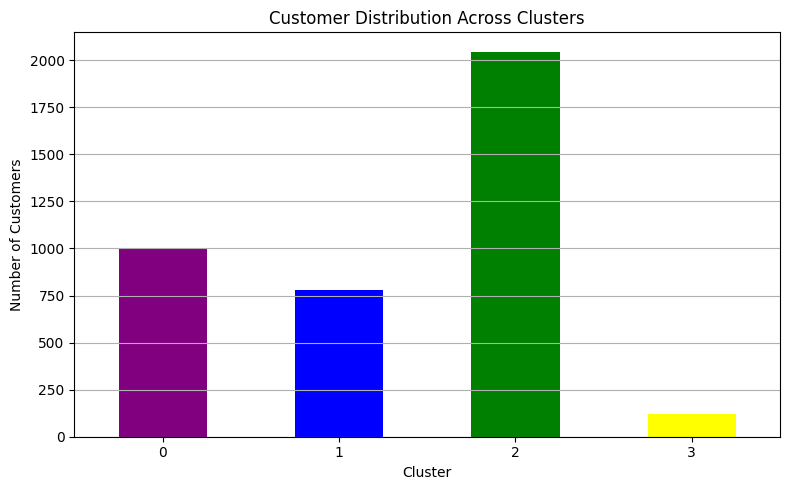

In [3]:
# Visualize cluster profiles using heatmap
cluster_profiles_mean = data.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profiles_mean.T, annot=True, fmt='.2f', cmap='coolwarm', cbar_kws={'label': 'Scaled Value'})
plt.title('Cluster Profiles - Mean Scaled Values')
plt.xlabel('Cluster')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Also create a bar plot for cluster sizes
plt.figure(figsize=(8, 5))
data['Cluster'].value_counts().sort_index().plot(kind='bar', color=['purple', 'blue', 'green', 'yellow'])
plt.title('Customer Distribution Across Clusters')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Segment Naming and Recommendations

Based on the cluster profiles, we will assign names to each segment and provide marketing recommendations.

In [4]:
# Analyze cluster characteristics to define segments
cluster_stats = data.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print("Cluster Statistics (Scaled Values):")
print(cluster_stats.round(3))
print("\n")

# Define segment names based on RFM characteristics
# Recency: lower is better (more recent), Frequency: higher is better, Monetary: higher is better
segment_names = {
    0: 'At-Risk Customers',      # High recency (not recent), low frequency, low monetary
    1: 'Valuable Customers',      # Low recency (recent), high frequency, high monetary  
    2: 'Loyal Customers',         # Low-mid recency, mid frequency, mid monetary
    3: 'VIP Customers'            # Very recent, very high frequency/monetary
}

recommendations = {
    0: '🚨 Re-engagement campaigns, special discounts, check-in surveys to understand churn reasons',
    1: '⭐ Premium loyalty programs, exclusive early access to new products, VIP events',
    2: '💼 Cross-sell and upsell opportunities, mid-tier rewards program, seasonal promotions',
    3: '👑 Dedicated account manager, premium customer service, personalized offers'
}

# Display insights
print("\n" + "="*70)
print("SEGMENT ANALYSIS & RECOMMENDATIONS")
print("="*70 + "\n")

for cluster in sorted(segment_names.keys()):
    size = len(data[data['Cluster'] == cluster])
    pct = (size / len(data)) * 100
    print(f"Cluster {cluster}: {segment_names[cluster]}")
    print(f"  📊 Size: {size} customers ({pct:.1f}%)")
    print(f"  📈 Characteristics: Recency={cluster_stats.loc[cluster, 'Recency']:.2f}, "
          f"Frequency={cluster_stats.loc[cluster, 'Frequency']:.2f}, "
          f"Monetary={cluster_stats.loc[cluster, 'Monetary']:.2f}")
    print(f"  💡 Recommendation: {recommendations[cluster]}")
    print()

Cluster Statistics (Scaled Values):
         Recency  Frequency  Monetary
Cluster                              
0          1.512     -0.502    -0.628
1         -0.577      0.770     1.478
2         -0.477     -0.286    -0.362
3         -0.725      3.970     1.787



SEGMENT ANALYSIS & RECOMMENDATIONS

Cluster 0: At-Risk Customers
  📊 Size: 1002 customers (25.4%)
  📈 Characteristics: Recency=1.51, Frequency=-0.50, Monetary=-0.63
  💡 Recommendation: 🚨 Re-engagement campaigns, special discounts, check-in surveys to understand churn reasons

Cluster 1: Valuable Customers
  📊 Size: 778 customers (19.7%)
  📈 Characteristics: Recency=-0.58, Frequency=0.77, Monetary=1.48
  💡 Recommendation: ⭐ Premium loyalty programs, exclusive early access to new products, VIP events

Cluster 2: Loyal Customers
  📊 Size: 2046 customers (51.8%)
  📈 Characteristics: Recency=-0.48, Frequency=-0.29, Monetary=-0.36
  💡 Recommendation: 💼 Cross-sell and upsell opportunities, mid-tier rewards program, seasonal promot

## Conclusion

In this notebook, we have generated insights from the clustered customer data, profiled each segment, visualized the differences, and provided actionable recommendations for marketing strategies.